# Champagne Forecasting: Full Model Walkthrough

This notebook now runs each model directly so you can inspect results per model:

1. SARIMA
2. XGBoost
3. PyTorch LSTM

Definitions remain in the src modules, but training, forecasting, metrics, and plots are executed here step by step.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd

from src.data import load_monthly_sales
from src.dl import recursive_lstm_forecast, train_lstm
from src.metrics import evaluate_forecast
from src.ml import recursive_xgboost_forecast, tune_xgboost_with_tscv
from src.statistical import forecast_sarima

DATA_PATH = Path("data/perrin-freres-monthly-champagne.csv")
TEST_HORIZON = 24
LSTM_EPOCHS = 300

series = load_monthly_sales(DATA_PATH)
train = series.iloc[:-TEST_HORIZON]
test = series.iloc[-TEST_HORIZON:]

predictions = {}
metadata = {}
run_times = {}

pd.DataFrame(
    {
        "train_start": [train.index.min()],
        "train_end": [train.index.max()],
        "test_start": [test.index.min()],
        "test_end": [test.index.max()],
        "train_points": [len(train)],
        "test_points": [len(test)],
    }
)

,train_start,train_end,test_start,test_end,train_points,test_points
0,1964-01-01,1970-09-01,1970-10-01,1972-09-01,81,24


In [2]:
sarima_start = perf_counter()
sarima_forecast, sarima_meta = forecast_sarima(
    train=train,
    horizon=len(test),
    seasonal_period=12,
)
run_times["SARIMA"] = perf_counter() - sarima_start
predictions["SARIMA"] = sarima_forecast
metadata["SARIMA"] = sarima_meta

sarima_metrics = evaluate_forecast(test, sarima_forecast)
pd.DataFrame([{"Model": "SARIMA", **sarima_metrics, "Seconds": run_times["SARIMA"]}])

,Model,RMSE,MAE,MAPE,Seconds
0,SARIMA,914.811198,788.617999,15.968054,21.90738


### SARIMA configuration selected by AIC

The model metadata is stored in metadata["SARIMA"]. The next cell visualizes SARIMA predictions against the hold-out period.

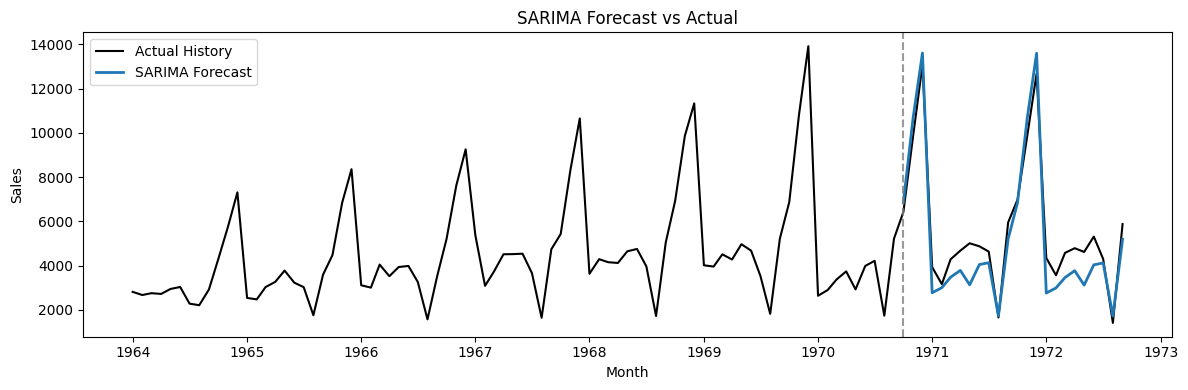

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(series.index, series.values, label="Actual History", color="black", linewidth=1.5)
plt.plot(test.index, sarima_forecast.values, label="SARIMA Forecast", linewidth=2)
plt.axvline(test.index[0], color="gray", linestyle="--", alpha=0.8)
plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

## 2) XGBoost (Feature-Based ML)

In [4]:
xgb_start = perf_counter()
xgb_model, xgb_features, xgb_meta = tune_xgboost_with_tscv(train_series=train)
xgb_forecast = recursive_xgboost_forecast(
    model=xgb_model,
    train_series=train,
    forecast_index=test.index,
    feature_columns=xgb_features,
)
run_times["XGBoost"] = perf_counter() - xgb_start
predictions["XGBoost"] = xgb_forecast
metadata["XGBoost"] = xgb_meta

xgb_metrics = evaluate_forecast(test, xgb_forecast)
pd.DataFrame([{"Model": "XGBoost", **xgb_metrics, "Seconds": run_times["XGBoost"]}])

,Model,RMSE,MAE,MAPE,Seconds
0,XGBoost,698.210484,573.204229,12.185182,10.558215


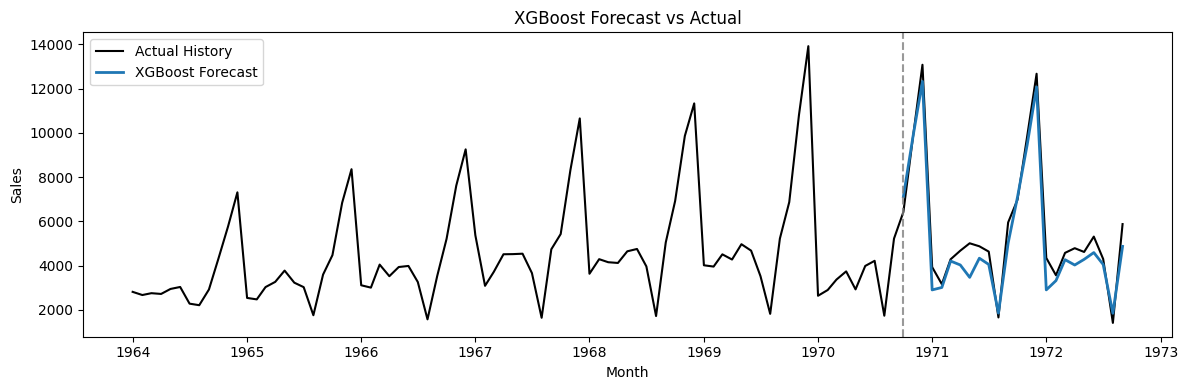

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(series.index, series.values, label="Actual History", color="black", linewidth=1.5)
plt.plot(test.index, xgb_forecast.values, label="XGBoost Forecast", linewidth=2)
plt.axvline(test.index[0], color="gray", linestyle="--", alpha=0.8)
plt.title("XGBoost Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

## 3) PyTorch LSTM (Sequence Deep Learning)

In [6]:
lstm_start = perf_counter()
lstm_artifacts = train_lstm(train_series=train, max_epochs=LSTM_EPOCHS)
lstm_values = recursive_lstm_forecast(
    artifacts=lstm_artifacts,
    train_series=train,
    forecast_horizon=len(test),
)
lstm_forecast = pd.Series(lstm_values, index=test.index, name="lstm")
run_times["LSTM"] = perf_counter() - lstm_start
predictions["LSTM"] = lstm_forecast
metadata["LSTM"] = lstm_artifacts.metadata

lstm_metrics = evaluate_forecast(test, lstm_forecast)
pd.DataFrame([{"Model": "LSTM", **lstm_metrics, "Seconds": run_times["LSTM"]}])

,Model,RMSE,MAE,MAPE,Seconds
0,LSTM,717.572461,536.186198,14.25055,4.412112


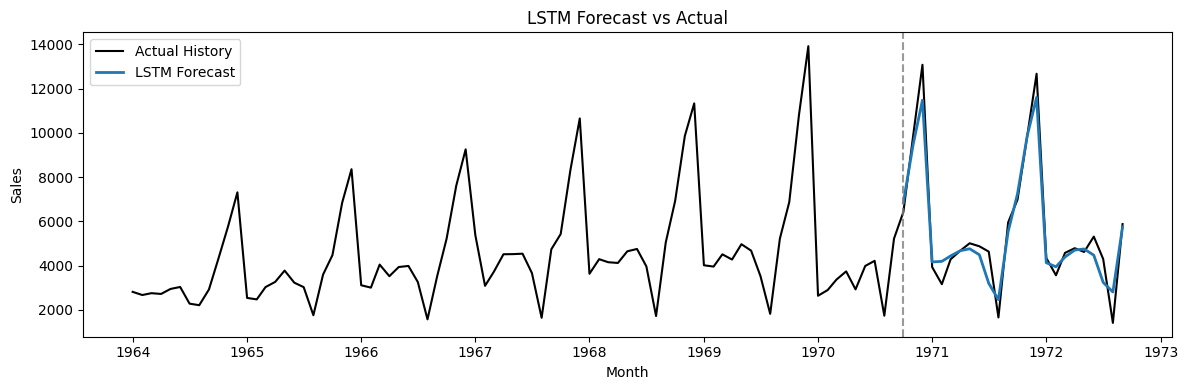

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(series.index, series.values, label="Actual History", color="black", linewidth=1.5)
plt.plot(test.index, lstm_forecast.values, label="LSTM Forecast", linewidth=2)
plt.axvline(test.index[0], color="gray", linestyle="--", alpha=0.8)
plt.title("LSTM Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

## 4) Final Comparison and Metadata

In [8]:
summary_rows = []
for model_name in ["SARIMA", "XGBoost", "LSTM"]:
    metric = evaluate_forecast(test, predictions[model_name])
    summary_rows.append(
        {
            "Model": model_name,
            **metric,
            "Train+Forecast Seconds": run_times[model_name],
        }
    )

summary_table = pd.DataFrame(summary_rows).sort_values("RMSE").reset_index(drop=True)
summary_table

,Model,RMSE,MAE,MAPE,Train+Forecast Seconds
0,XGBoost,698.210484,573.204229,12.185182,10.558215
1,LSTM,717.572461,536.186198,14.250550,4.412112
2,SARIMA,914.811198,788.617999,15.968054,21.907380


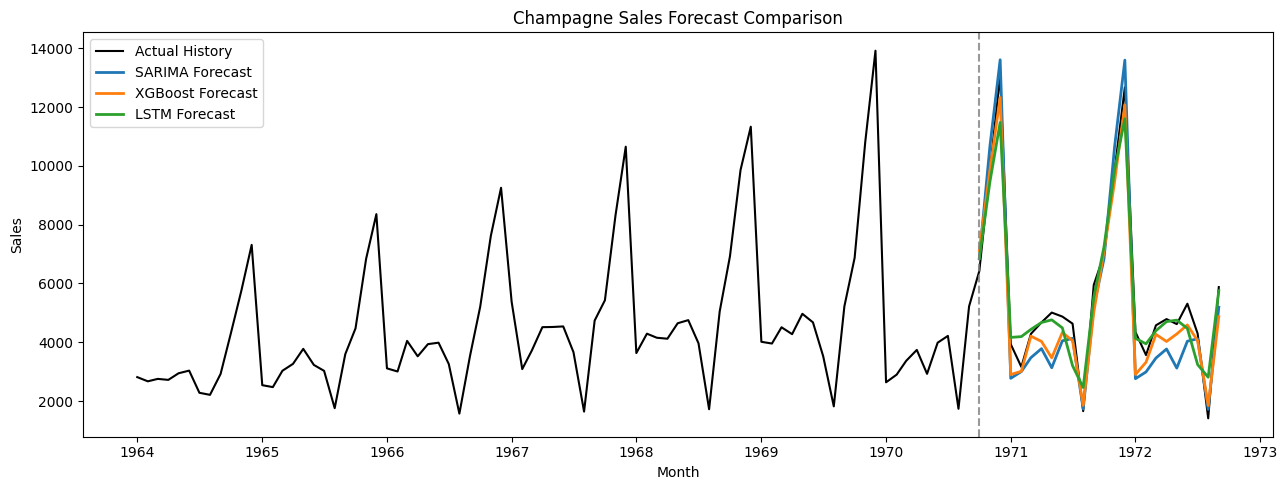

In [9]:
plt.figure(figsize=(13, 5))
plt.plot(series.index, series.values, label="Actual History", color="black", linewidth=1.5)
for model_name in ["SARIMA", "XGBoost", "LSTM"]:
    plt.plot(test.index, predictions[model_name].values, label=f"{model_name} Forecast", linewidth=2)

plt.axvline(test.index[0], color="gray", linestyle="--", alpha=0.8)
plt.title("Champagne Sales Forecast Comparison")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
metadata

{'SARIMA': {'order': (0, 1, 2),
  'seasonal_order': (0, 1, 1, 12),
  'aic': 872.321,
  'candidates_tried': 144},
 'XGBoost': {'cv_rmse': 961.821,
  'n_estimators': 400.0,
  'max_depth': 3.0,
  'learning_rate': 0.03,
  'subsample': 0.8,
  'colsample_bytree': 1.0},
 'LSTM': {'epochs_trained': 122, 'best_valid_mse': 0.24671}}